<a href="https://colab.research.google.com/github/pabloecheg/Unsupervised-Learning/blob/main/RETO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd # manejo de Data Frame en Python
pd.set_option('display.max_columns', 50) # Mostrar mas columnas
import numpy as np
# Librería de gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# Segmentación
from sklearn.cluster import KMeans # K-means
from sklearn.metrics import silhouette_score # Score selección de clúster
from sklearn.preprocessing import StandardScaler # Estandarización

In [ ]:
data = pd.read_csv ('/content/drive/MyDrive/APRENDIZAJE NO SUPERVISADO/BASES DE DATOS/marketing_campaign.csv', sep= "\t")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
data = data.dropna()
data.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
data1 = data.copy()

In [ ]:
data1.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
data1["Age"] = 2024-data["Year_Birth"] #Calcular la edad y crear una nueva columna
data1["Age"]

,Age
0,67
1,70
2,59
3,40
4,43
...,...
2235,57
2236,78
2237,43
2238,68


In [ ]:
data1['Numkids'] = data1['Kidhome']+data1['Teenhome']
data1['Numkids']

,Numkids
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [ ]:
data1['TotalSpend'] = data1['MntWines']+data1['MntFruits']+data1['MntMeatProducts']+data1['MntFishProducts']+data1['MntSweetProducts']+data1['MntGoldProds']
data1['TotalSpend']

,TotalSpend
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [ ]:
data1["Numcmp"] = data1[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)
data1["Numcmp"]

,Numcmp
0,0
1,0
2,0
3,0
4,0
...,...
2235,0
2236,1
2237,1
2238,0


In [ ]:
data1.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Numkids,TotalSpend,Numcmp
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,67,0,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,70,2,27,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,59,0,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,40,1,53,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,43,1,422,0


In [ ]:
keep_columns = ['Age', 'Numkids', 'TotalSpend', 'Numcmp', 'Income', 'NumWebVisitsMonth', 'Education']
data1 = data1[keep_columns]
data1.head()

,Age,Numkids,TotalSpend,Numcmp,Income,NumWebVisitsMonth,Education
0,67,0,1617,0,58138.0,7,Graduation
1,70,2,27,0,46344.0,5,Graduation
2,59,0,776,0,71613.0,4,Graduation
3,40,1,53,0,26646.0,6,Graduation
4,43,1,422,0,58293.0,5,PhD


In [ ]:
data1.describe()

,Age,Numkids,TotalSpend,Numcmp,Income,NumWebVisitsMonth
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,55.179603,0.947202,607.075361,0.298285,52247.251354,5.319043
std,11.985554,0.749062,602.900476,0.679209,25173.076661,2.425359
min,28.000000,0.000000,5.000000,0.000000,1730.000000,0.000000
25%,47.000000,0.000000,69.000000,0.000000,35303.000000,3.000000
50%,54.000000,1.000000,396.500000,0.000000,51381.500000,6.000000
75%,65.000000,1.000000,1048.000000,0.000000,68522.000000,7.000000
max,131.000000,3.000000,2525.000000,4.000000,666666.000000,20.000000


**Edad**: El rango de edad varía desde los 28 años hasta los 131, lo que nos podría indicar que hay errores en los datos, o que la compañía no elimina los clientes fallecidos. El cliente promedio tiene 55 años.

In [ ]:
px.box(data1,y="Age", title="Rango de Edad" )

**Numero de Hijos**: Los clientes tienen desde 0 a 3 hijos, y se podría decir que el cliente promedio tiene al menos un hijo.

In [ ]:
px.pie(data1, names = "Numkids", title="Numero de Hijos")

**Gasto Total:** El cliente promedio gasta 607 dolares en productos, pero el gasto va desde 5 Dolares hasta 2525 Dolares.

In [ ]:
px.box(data1,y="TotalSpend", title="Gasto Total" )

**Numero de Promociones:** Casi el 80% de los clientes no aceptan ninguna campaña.

In [ ]:
px.pie(data1, names = "Numcmp", title="Numero de Promociones Aceptadas")

**Ingreso:** El cliente promedio gana 52,247 dolares. Pero hay clientes que ganan 1,730 hasta 666,666 Dolares.

In [ ]:
px.box(data1,y="Income", title="Ingreso" )

**Numero de Visitas Pagina Web:** El cliente promedio visita la pagina 5 veces por mes, pero tambien hay clientes que no la visitan, o la visitan 20 veces.

In [ ]:
px.box(data1,y="NumWebVisitsMonth", title="Numero de Visitas Pagina Web" )

Transformacion de Variables Categoricas a **dummy**

De data1 podemos decir que 'Tiene Hijos' y 'Education' son categoricas

In [ ]:
data1['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [ ]:
data1 = pd.get_dummies(data1, columns=['Education'])

In [ ]:
data1.head()

,Age,Numkids,TotalSpend,Numcmp,Income,NumWebVisitsMonth,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,67,0,1617,0,58138.0,7,False,False,True,False,False
1,70,2,27,0,46344.0,5,False,False,True,False,False
2,59,0,776,0,71613.0,4,False,False,True,False,False
3,40,1,53,0,26646.0,6,False,False,True,False,False
4,43,1,422,0,58293.0,5,False,False,False,False,True


Estandarizacion de Variables

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data1)
scaled_features

array([[ 0.98644293, -1.26480327,  1.67548812, ...,  0.99280566,
        -0.4440616 , -0.52652961],
       [ 1.23680074,  1.40580564, -0.96235832, ...,  0.99280566,
        -0.4440616 , -0.52652961],
       [ 0.31882209, -1.26480327,  0.28024985, ...,  0.99280566,
        -0.4440616 , -0.52652961],
       ...,
       [-1.01641959, -1.26480327,  1.05169551, ...,  0.99280566,
        -0.4440616 , -0.52652961],
       [ 1.06989553,  0.07050118,  0.39140438, ..., -1.00724647,
         2.2519398 , -0.52652961],
       [ 1.23680074,  1.40580564, -0.7218    , ..., -1.00724647,
        -0.4440616 ,  1.89922842]])

Aplicar K-Means

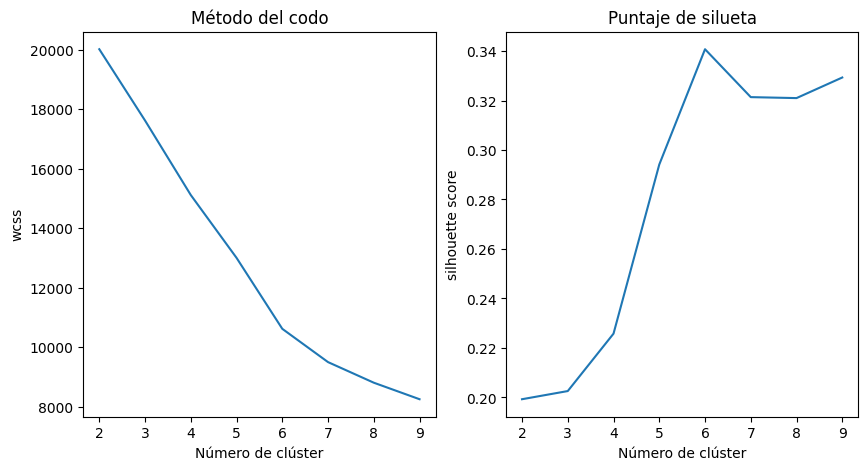

In [ ]:
silueta_score=[] # puntaje de silueta
wcss =[] #
n_clusters= range( 2,10)
for k in n_clusters:
  k_means=KMeans(k, random_state=1017923112)
  k_means.fit(scaled_features)
  wcss.append(k_means.inertia_ )
  silueta = silhouette_score(scaled_features, k_means.labels_)
  silueta_score.append(silueta)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(n_clusters,wcss)
axs[0].set_title("Método del codo")
axs[0].set_xlabel("Número de clúster" )
axs[0].set_ylabel("wcss" )
axs[1].plot( n_clusters,silueta_score)
axs[1].set_title("Puntaje de silueta")
axs[1].set_xlabel("Número de clúster" )
axs[1].set_ylabel("silhouette score" )
plt.show()

Segun el metodo del codo, el punto de inflexión serian 6 clusteres, pero no esta muy marcado. Por esto, será mejor hacerle caso al puntaje de silueta que nos indica que hay un puntaje máximo al implementar **6 clusteres.**

In [ ]:
k_means=KMeans(6, random_state = 1017923113)
k_means.fit(scaled_features )
data1["labels_k_means"]= k_means.labels_
data1["labels_k_means"] = data1["labels_k_means"].astype(str)
data1["labels_k_means"].value_counts()

,count
labels_k_means,
4,793
1,429
0,413
5,331
3,196
2,54


Al observar la cantidad de datos en cada cluster, podemos ver que los clusteres estan repartidos relativamente equitativos, exceptuando el numero 2; que tiene 54 registros.

En caso tal de que se cambiara el numero de clusters a 8, los mismos 54 registros siguen estando aparte. Por que?

**Hierarchical Clustering**

In [ ]:
import pandas as pd # Manejo de Data Frame
import numpy as np # Manejo matricial
import warnings # Omitir warnings
warnings.filterwarnings("ignore") # Ignorar warning (me estresan los warnings >:|)
# librerías para Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# Librerías para clustering
from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import dendrogram,  linkage # Dendograma
# Score de silueta
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from sklearn.preprocessing import StandardScaler # estandarizar variables.

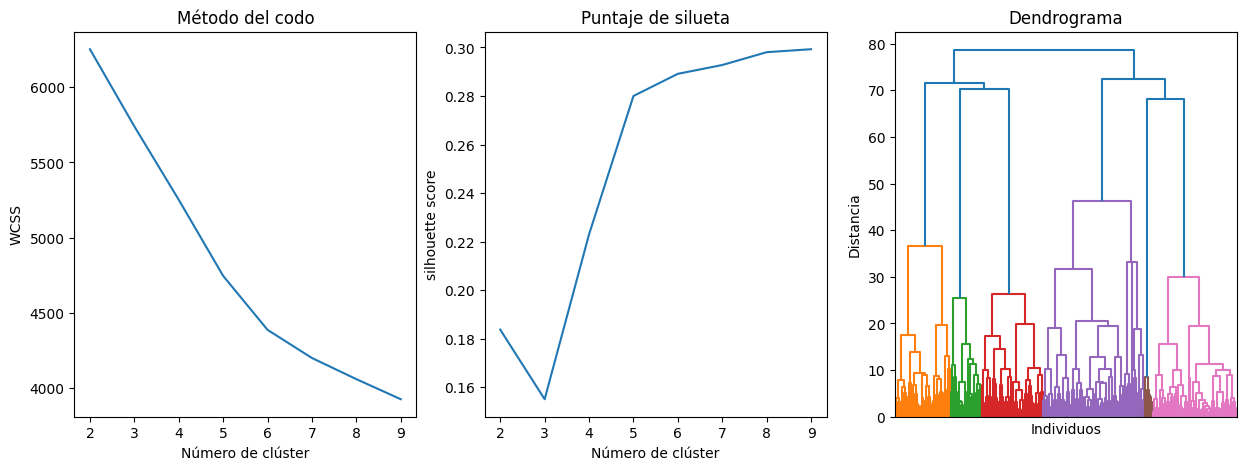

In [ ]:
silueta =[]
wcss =[]
n_cluster=range(2,10)
for i in n_cluster:
  jerarquico = AgglomerativeClustering(i)
  jerarquico.fit(scaled_features)
  scaled_temp= pd.DataFrame(scaled_features)
  scaled_temp["labels"]=jerarquico.labels_
  centros= scaled_temp.groupby("labels").mean()  # obteniendo centros
  argmin, distance =pairwise_distances_argmin_min(scaled_features,centros  )  # obteniendo distancias
  wcss.append(np.sum(distance) )
  score = silhouette_score(scaled_features,jerarquico.labels_ )
  silueta.append(score)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot( (n_cluster), wcss  )
axes[0].set_ylabel("WCSS")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clúster" )
axes[1].plot( (n_cluster), silueta  )
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Puntaje de silueta")
axes[1].set_xlabel("Número de clúster" )

# visualización clustering jerarquico
dist_matrix = linkage(scaled_features, method='ward')
# Visualizar el dendrograma
dendrogram(dist_matrix,no_labels=True)
axes[2].set_title('Dendrograma')
axes[2].set_xlabel('Individuos')
axes[2].set_ylabel('Distancia')
plt.show()


In [ ]:
hc=AgglomerativeClustering(5)
hc.fit(scaled_features )
data1["labels_hc"]= hc.labels_
data1["labels_hc"] = data1["labels_hc"].astype(str)
data1["labels_hc"].value_counts()

,count
labels_hc,
2,661
0,596
3,396
1,363
4,200


# **Interpretacion de Resultados**

K-Means

labels_k_means
4    0.357852
1    0.193592
0    0.186372
5    0.149368
3    0.088448
2    0.024368
Name: proportion, dtype: float64


<Axes: xlabel='labels_k_means', ylabel='proportion'>

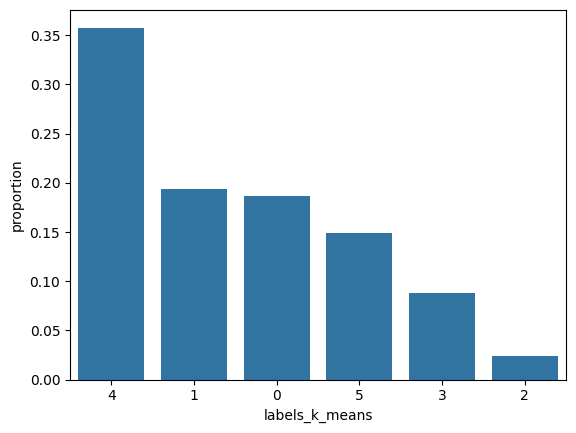

In [ ]:
print(data1["labels_k_means"].value_counts(normalize=True))
sns.barplot(data1["labels_k_means"].value_counts(normalize=True) )

Podemos observar que en el cluster #4, estan el 35% de los clientes mientras que en el cluster #2, estan apenas el 2.4% .

Hierarchical Clustering

labels_hc
2    0.298285
0    0.268953
3    0.178700
1    0.163809
4    0.090253
Name: proportion, dtype: float64


<Axes: xlabel='labels_hc', ylabel='proportion'>

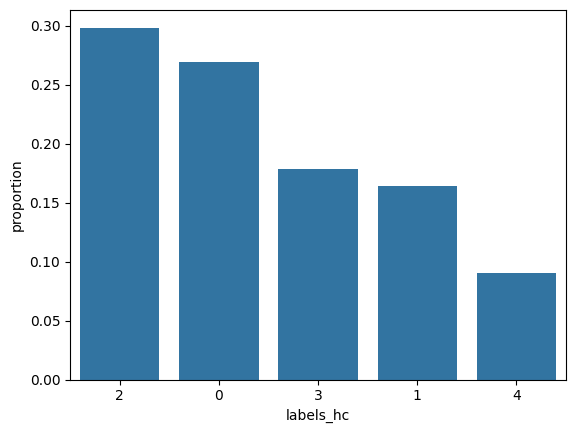

In [ ]:
print(data1["labels_hc"].value_counts(normalize=True))
sns.barplot(data1["labels_hc"].value_counts(normalize=True) )

Para el hierarchical clustering, el caso es un poco parecido. El cluster #2 representa el 29% de los clientes, mientras que el cluster #4 solamente representa el 9%

In [ ]:
data1.columns

Index(['Age', 'Numkids', 'TotalSpend', 'Numcmp', 'Income', 'NumWebVisitsMonth',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'labels_k_means', 'labels_hc'],
      dtype='object')

## Graficos Con Variables de Interes

### Age

K-Means

In [ ]:
px.box(data1, x='labels_k_means', y='Age',color="labels_k_means",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Age: Boxplot por clúster')

Si observamos el cluster #2, que es el cluster particular, en el boxplot con relacion a la edad, es el cluster que tiene clientes mas jovenes. Con una edad media de 45.

Hierarchical Clustering

In [ ]:
px.box(data1, x='labels_hc', y='Age',color="labels_hc",
      # points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Age: Boxplot por clúster')

Al igual que en el caso de K-Means, el cluster con menos registros que sería el #4, tiene la edad media mas baja: de 49 años. De resto, no hay nada distinctivo si exceptuamos los datos atipicos que serian 124 y 131 años.

### Numero de Hijos

K-Means

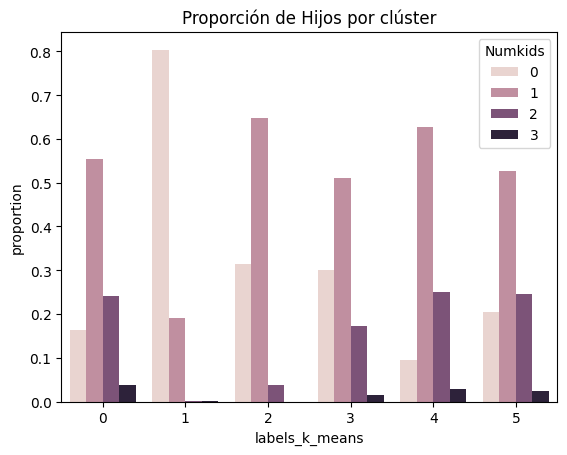

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_k_means')['Numkids'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_k_means', y='proportion', hue='Numkids')
plt.title('Proporción de Hijos por clúster')
plt.show()

Respecto al cluster #2, que es el que menos registros tiene, no hay nada de particular. Pero si observamos los otros, podemos ver que el cluster #1 es el que menos hijos tiene (alrederor del 80% de clientes no tiene hijos).

Hierarchical Clustering

In [ ]:
data1.groupby('labels_hc')['Numkids'].value_counts(normalize=True)

labels_hc  Numkids
0          1          0.592282
           2          0.298658
           0          0.075503
           3          0.033557
1          1          0.482094
           0          0.272727
           2          0.223140
           3          0.022039
2          0          0.564297
           1          0.391831
           2          0.039334
           3          0.004539
3          1          0.580808
           2          0.244949
           0          0.133838
           3          0.040404
4          1          0.500000
           0          0.315000
           2          0.170000
           3          0.015000
Name: proportion, dtype: float64

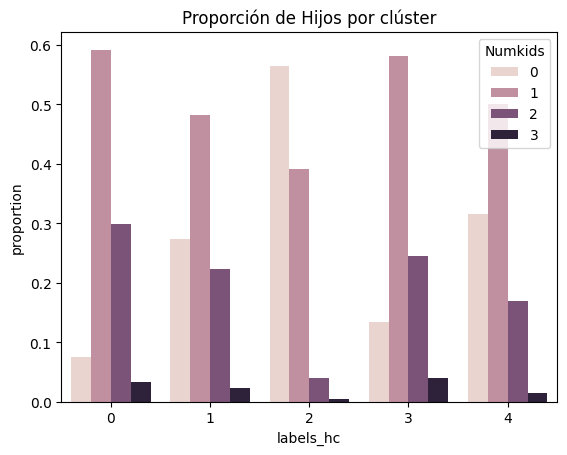

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_hc')['Numkids'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_hc', y='proportion', hue='Numkids')
plt.title('Proporción de Hijos por clúster')
plt.show()

El cluster #0 es el que mas hijos tiene, ya que alrededor del 90% de los clientes que pertenencen a este cluster tienen hijos. Mientras el cluster con menos registros (Cluster #4) muestra un comportamiento un poco particular: Alrederor del 50% de los clientes dentro de este cluster tienen un hijo y alrededor del 30% no tienen hijos.

### Gasto Total

K-Means

In [ ]:
px.box(data1, x='labels_k_means', y='TotalSpend',color="labels_k_means",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Gasto Total: Boxplot por clúster')

Respecto al gasto, el cluster atípico (el #2) es el que menos gasta. Con un gasto maximo de 119 dolares, medio de 57 y minimo de 14. Mientras que el cluster #1 es el que mas gasta. Con un gasto maximo de 2525 dolares, medio de 1443 y minimo de 310.

Hierarchical Clustering

In [ ]:
px.box(data1, x='labels_hc', y='TotalSpend',color="labels_hc",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Gasto Total: Boxplot por clúster')

El cluster #2 es el que mas gasta, con un gasto maximo de 2524 dolares, medio de 1102 y mminimo de 6. Mientras que el cluster #4, que es el que menos registros tiene, no muestra ningun comportamiento atípico.

### Numero de Campañas Aceptadas

K-Means

In [ ]:
data1.groupby('labels_k_means')['Numcmp'].value_counts(normalize=True)

labels_k_means  Numcmp
0               0         0.832930
                1         0.142857
                2         0.021792
                3         0.002421
1               0         0.477855
                1         0.261072
                2         0.142191
                3         0.093240
                4         0.025641
2               0         0.888889
                1         0.111111
3               0         0.831633
                1         0.137755
                2         0.020408
                3         0.010204
4               0         0.895334
                1         0.099622
                2         0.005044
5               0         0.867069
                1         0.120846
                2         0.009063
                3         0.003021
Name: proportion, dtype: float64

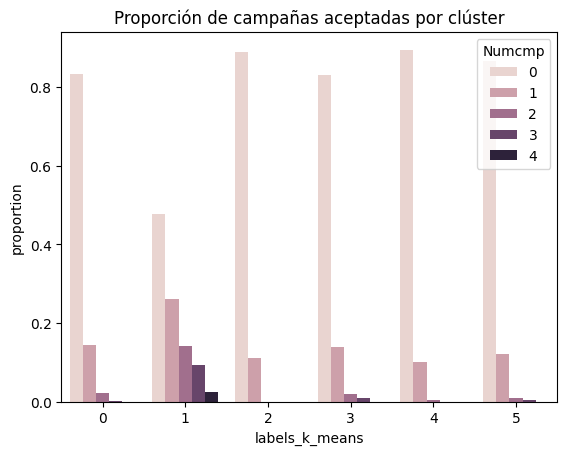

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_k_means')['Numcmp'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_k_means', y='proportion', hue='Numcmp')
plt.title('Proporción de campañas aceptadas por clúster')
plt.show()

Respecto a las campañas aceptadas, el cluster atípico (#2) es el que menos campañas acepta. Podemos observar que el 88% de clientes dentro de este cluster no aceptaron ninguna campaña, y solamente el 10% de clientes aceptó 1.

Tambien podemos ver que el 53% de los clientes dentro del cluster #1 aceptaron almenos una campaña, siendo el cluster que mas promociones acepta.

Hierarchical Clustering

In [ ]:
data1.groupby('labels_hc')['Numcmp'].value_counts(normalize=True)

labels_hc  Numcmp
0          0         0.953020
           1         0.046980
1          0         0.796143
           1         0.148760
           2         0.035813
           3         0.016529
           4         0.002755
2          0         0.623298
           1         0.234493
           2         0.077156
           3         0.049924
           4         0.015129
3          0         0.820707
           1         0.148990
           2         0.025253
           3         0.005051
4          0         0.815000
           1         0.135000
           2         0.035000
           3         0.015000
Name: proportion, dtype: float64

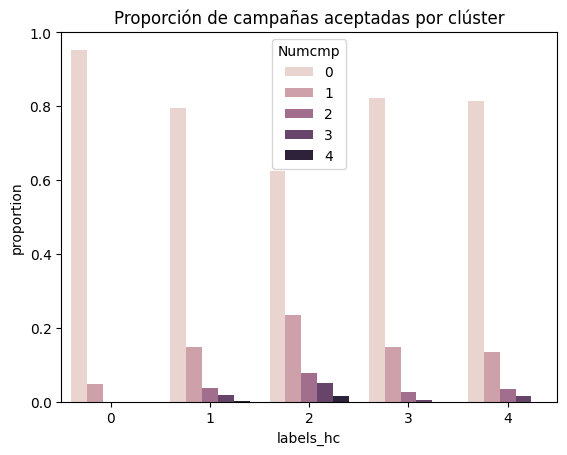

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_hc')['Numcmp'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_hc', y='proportion', hue='Numcmp')
plt.title('Proporción de campañas aceptadas por clúster')
plt.show()

El cluster #0, es el que acepta menos campañas: con un 95% de clientes que no aceptaron ninguna promocion.

El cluster que mas aceptó campañas fue el #2. El 38% de los clientes dentro de este cluster aceptaron almenos una campaña.

El cluster #4, que es el que mas nos intriga, tuvo un comportamiento casi identico al cluster #3. Ninguno de estos clusteres nos mostró algun comportamiento atípico.

### Income

K-Means

In [ ]:
px.box(data1, x='labels_k_means', y='Income',color="labels_k_means",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Ingreso: Boxplot por clúster')

El cluster #1 es el que mas ingresos tiene: con un ingreso medio de 77,382 dolares. Presenta datos atípicos como ingresos de 666,666 dolares.

El cluster atípico (el #2) es el que menos ingresos tiene: con un ingreso medio de 20,844 dolares.


Hierarchical Clustering

In [ ]:
px.box(data1, x='labels_hc', y='Income',color="labels_hc",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Ingreso: Boxplot por clúster')

El cluster #2 es el que mas ingresos tiene. Presentando un ingreso medio de 70,321 dolares y presenta datos atipicos como: ingresos de 666,666 dolares.

El cluster #0 es el que menos ingresos presenta: con ingresos medios de 34,716 dolares.

### Numero de Visitas Web / Mes

K-Means

In [ ]:
px.box(data1, x='labels_k_means', y='NumWebVisitsMonth',color="labels_k_means",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Numero de Visitas Web: Boxplot por clúster')

Los cluster #4 y #2 (atípico) son losque mas Visitas Web / Mes presentan: con 7 visitas promedio por mes.

El cluster #1 es el que menos visitas/mes tiene. Con 2 visitas promedio en un mes.


Hierarchical Clustering

In [ ]:
px.box(data1, x='labels_hc', y='NumWebVisitsMonth',color="labels_hc",
       #points=False, # No muestra los puntos atípicos extendiendo las barras
             title='Numero de Visitas Web: Boxplot por clúster')

El cluster que mas visita la pagina web/mes es el cluster #0. Tiene 0 visitas medias, pero tiene bastantes clientes que superan de lejos este promedio.

El cluster que menos visita la pagina web es el cluster #2: Con visitas medias de 3 veces/mes.

In [ ]:
data1.columns

Index(['Age', 'Numkids', 'TotalSpend', 'Numcmp', 'Income', 'NumWebVisitsMonth',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'labels_k_means', 'labels_hc'],
      dtype='object')

### Education

K-Means

In [ ]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
data1['Education']=data["Education"]

In [ ]:
data1['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [ ]:
data1.groupby('labels_k_means')['Education'].value_counts(normalize=True)

labels_k_means  Education 
0               PhD           1.000000
1               Graduation    0.752914
                PhD           0.158508
                Master        0.079254
                2n Cycle      0.009324
2               Basic         1.000000
3               2n Cycle      1.000000
4               Graduation    1.000000
5               Master        1.000000
Name: proportion, dtype: float64

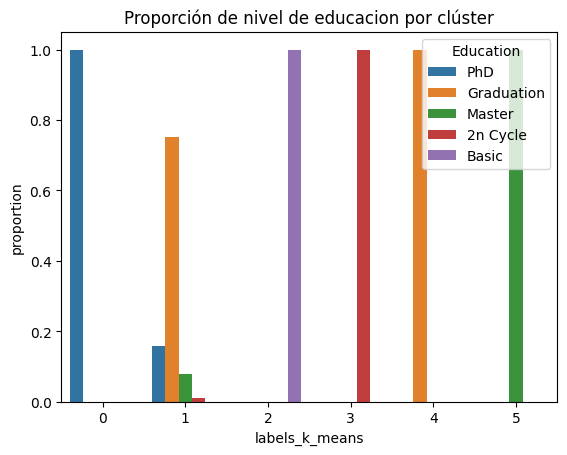

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_k_means')['Education'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_k_means', y='proportion', hue='Education')
plt.title('Proporción de nivel de educacion por clúster')
plt.show()

Podemos ver que basicamente, un cluster es un grado de educación. Exceptuando el cluster #1, que recoge un poco de todos menos la educacion Basica.

El cluster #2, que solamente recogía 54 clientes incluye el 100% de los clientes con Educacion Basica.

Hierarchical Clustering

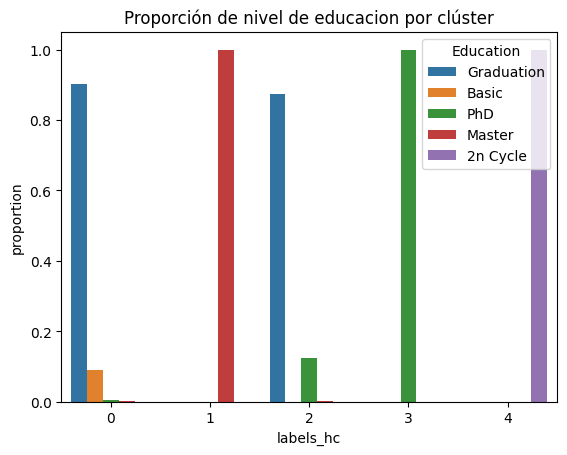

In [ ]:
tabla_frecuencia_relacion= data1.groupby('labels_hc')['Education'].value_counts(normalize=True)
sns.barplot(data=tabla_frecuencia_relacion.reset_index(), x='labels_hc', y='proportion', hue='Education')
plt.title('Proporción de nivel de educacion por clúster')
plt.show()

Este caso es un poco similar al de K-means, ya que cada cluster es basicamente un grado de educacion. Exceptuando el cluster #0 y #2.

# Conclusion General

Para este tipo de problematica, pensaría que el Clustering con K-Means es mas adecuado ya que con K-Means, el algoritmo nos separó 54 clientes que en varias ocasiones tenian comportamientos diferentes al resto.

Al final nos dimos cuenta que el cluster #2 eran los unicos clientes que tenían Educación Basica, por esto los separó. Estos clientes eran los mas jovenes, los que menos ganaban, los que menos gastaban, pero tambien eran los que mas visitaban la página web.

Esta clusterización nos permitió ver los datos separando los clientes de interés, de los que no. Por esto, me pareció mas efectiva en este caso la clusterización con K-Means.




### Recomendación

Si fuera el encargado de esta compañía, seleccionaría a estos clientes con Educacion Basica a ofrecerle otro tipo de productos que se acople a sus necesidades.

Este tipo de clientes con bajos ingresos, y poca educación suele consumir productos de preparación rapida, comida rapida o snacks.